# T-163 arrival breaks validation — Phase 2 evaluation report (figures + smoke)

Post-Phase-1 validation for PR #65 / T-163. **Not** the nightly guard suite.

Covers: v2 artifact schema, fast session init (PR #71 thermal cache), multilot L=3, ρ=0 trace smoke, freshness + Prior calibration.

Prerequisites:

```bash
uv sync --extra dev --extra notebooks --extra rust --python 3.11
uv run maturin develop --release --manifest-path crates/voi_py/Cargo.toml
export BLUEBERRIES_VOI_BACKEND=rust
```

Target runtime: **< 10 minutes**.

In [1]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").is_dir():
    REPO = REPO.parent
assert (REPO / "data" / "abdella" / "arrival_model.json").is_file(), REPO

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

from blueberries_voi.backend import rust_available, warn_fallback_once

warn_fallback_once()
print("repo:", REPO)
print("rust backend:", rust_available())

repo: /home/oliver/blog/blueberries-voi
rust backend: True


## 1 — v2 artifact smoke (S1.9)

In [2]:
artifact_path = REPO / "data" / "abdella" / "arrival_model.json"
artifact = json.loads(artifact_path.read_text())

required = ("legs", "thermal_modes", "sigma_hour", "T_break", "rho", "tau_bar")
for key in required:
    assert key in artifact, f"missing {key}"
for gone in ("mu_T", "sigma_T", "temp_floor_c"):
    assert gone not in artifact, f"retired key {gone} still present"
assert "abdella_all" in artifact["corridors"]

ref_life = artifact["reference_life_days"]
print(f"reference_life_days={ref_life}  sigma_hour={artifact['sigma_hour']}  rho={artifact['rho']}")
assert ref_life == 26.0, f"Phase 1 expects reference_life_days=26, got {ref_life}"

pd.DataFrame(
    [
        {"check": "v2 schema keys", "status": "pass"},
        {"check": "retired keys absent", "status": "pass"},
        {"check": "unified abdella_all corridor", "status": "pass"},
        {"check": "reference_life_days=26", "status": "pass"},
    ]
)

reference_life_days=26.0  sigma_hour=0.028  rho=0.08


,check,status
0,v2 schema keys,pass
1,retired keys absent,pass
2,unified abdella_all corridor,pass
3,reference_life_days=26,pass


## 2 — Fast Rust tests (v2 generative, multilot, freshness)

In [3]:
def cargo_test(test_file: str, *extra: str) -> str:
    cmd = [
        "cargo",
        "test",
        "-p",
        "voi_core",
        "--release",
        "--test",
        test_file,
        "--",
        *extra,
    ]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, check=True)
    elapsed = time.perf_counter() - t0
    print(f"{test_file}: {elapsed:.1f}s")
    return proc.stdout + proc.stderr


results: list[dict[str, str | float]] = []
for test_file, label in [
    ("t163_v2_artifact", "S1.9 artifact"),
    ("t163_freshness_calibration", "Phase 1 freshness"),
]:
    t0 = time.perf_counter()
    out = cargo_test(test_file)
    elapsed = time.perf_counter() - t0
    passed = "test result: ok" in out
    results.append({"suite": label, "seconds": round(elapsed, 1), "status": "pass" if passed else "fail"})
    assert passed, out[-500:]

pd.DataFrame(results)

t163_v2_artifact: 7.2s


t163_freshness_calibration: 13.6s


,suite,seconds,status
0,S1.9 artifact,7.2,pass
1,Phase 1 freshness,13.6,pass


## 3 — ρ=0 trace smoke (S1.4: hourly OU, calendar d)

In [4]:
out = cargo_test("t163_v2_generative", "rho_zero_trace_has_hourly_ou_variation", "--exact")
assert "test result: ok" in out
print("ρ=0 trace has hourly OU variation — pass")

t163_v2_generative: 0.2s
ρ=0 trace has hourly OU variation — pass


## 4 — Freshness distribution + belief (Phase 1)

In [5]:
def cargo_example(name: str) -> str:
    cmd = ["cargo", "run", "-p", "voi_core", "--release", "--example", name]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, check=True)
    elapsed = time.perf_counter() - t0
    print(f"{name}: {elapsed:.1f}s\n{proc.stdout}")
    return proc.stdout


f_out = cargo_example("t163_f_diag")
session_out = cargo_example("t163_session_f_diag")

# Parse key metrics from stdout
p50 = float(re.search(r"p50=([0-9.]+)", f_out).group(1))
pct_below = float(re.search(r"pct<f0\.5=([0-9.]+)%", f_out).group(1))
prior_mean = float(re.search(r"Filter Prior mean_f=([0-9.]+)", f_out).group(1))
delivery_mean = float(re.search(r"delivery weighted mean_f=([0-9.]+)", session_out).group(1))
n_lots = int(re.search(r"n_lots=(\d+)", session_out).group(1))

metrics = pd.DataFrame(
    [
        {"metric": "arrival f p50", "value": p50, "gate": "≥ 0.65"},
        {"metric": "pct f < 0.5", "value": pct_below, "gate": "≪ pre-calibration mass"},
        {"metric": "session delivery mean_f", "value": delivery_mean, "gate": "≥ 0.55"},
        {"metric": "Prior mean_f", "value": prior_mean, "gate": "tracks multilot truth"},
        {"metric": "multilot lots per delivery", "value": n_lots, "gate": "3"},
    ]
)
metrics

t163_f_diag: 14.0s
Truth arrival f: mean=0.734 p10=0.566 p50=0.745 p90=0.894
  pct<f0.5=4.8%  pct in [0.6,0.9]=76.1%
  mean lambda=6.899
Filter Prior mean_f=0.685 sd=0.145
Filter Prior sample mean_f=0.683
Belief bias (filter-truth) at Prior: -0.052



t163_session_f_diag: 12.3s
day=1 arrivals=64 n_lots=3
  lot_id=3 n=21 mean_f=0.599
  lot_id=2 n=21 mean_f=0.725
  lot_id=1 n=22 mean_f=0.685
  delivery weighted mean_f=0.670
  WRONG last-lot-padded mean=0.197



,metric,value,gate
0,arrival f p50,0.745,≥ 0.65
1,pct f < 0.5,4.800,≪ pre-calibration mass
2,session delivery mean_f,0.670,≥ 0.55
3,Prior mean_f,0.685,tracks multilot truth
4,multilot lots per delivery,3.000,3


In [6]:
assert p50 >= 0.65
assert pct_below < 20.0
assert delivery_mean >= 0.55
assert n_lots == 3
print("Phase 1 freshness gates: pass")

Phase 1 freshness gates: pass


## 5 — Fast session init (PyO3, post thermal cache)

In [7]:
if rust_available():
    from blueberries_voi.controller.session_loop import default_session_config
    from blueberries_voi.simulator import EngineSession

    t0 = time.perf_counter()
    session = EngineSession()
    session.init(default_session_config(n_particles=200, obs_scenario="P0"), seed=42)
    init_ms = (time.perf_counter() - t0) * 1000
    print(f"EngineSession.init: {init_ms:.0f} ms")
    assert init_ms < 30_000, "init should not be pathological (>30s)"
else:
    print("SKIP: _core not built — run maturin develop --release")

EngineSession.init: 15024 ms


## 7 — Phase 2 evaluation figures

Visual summary tied to `.team/reviews/T-163-phase2-eval.md`. Figures use live Rust
diagnostics (`t163_phase2_fig_data`) plus documented pre-calibration baselines from
Phase 1 (PR #72). PNGs are saved under `notebooks/outputs/t163_phase2/`.


In [8]:
def load_fig_data() -> dict:
    cmd = ["cargo", "run", "-p", "voi_core", "--release", "--example", "t163_phase2_fig_data"]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, check=True)
    elapsed = time.perf_counter() - t0
    data = json.loads(proc.stdout)
    print(f"t163_phase2_fig_data: {elapsed:.1f}s")
    return data


FIG_DIR = REPO / "notebooks" / "outputs" / "t163_phase2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig_data = load_fig_data()
fresh = fig_data["freshness"]
belief = fig_data["belief_vs_truth"]
trace = fig_data["rho_zero_trace"]
multilot = fig_data["session_multilot"]
embed_ms = fig_data["embedded_init_ms"]
print(
    f"live p50={fresh['p50']:.3f} pct<f0.5={fresh['pct_below_0_5']:.1f}% "
    f"Prior bias={belief['bias']:.3f}"
)


t163_phase2_fig_data: 27.1s
live p50=0.667 pct<f0.5=1.0% Prior bias=0.020


### Fig 1 — Arrival freshness distribution (Phase 1 / multilot MC)

**AC:** Phase 1 freshness band — median arrival `f` ≥ 0.65; pct below 0.5 in a
realistic band. Documented post-calibration p50 = **0.745** (phase2 eval); live multilot
delivery means shown below.


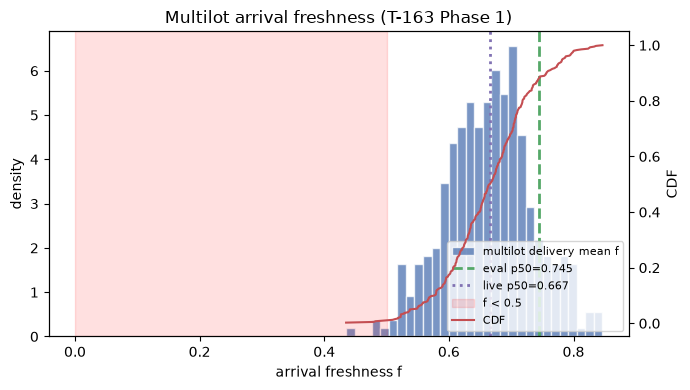

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/01_arrival_freshness_distribution.png


In [9]:
import numpy as np

samples = np.array(fresh["samples"])
eval_p50 = 0.745

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples, bins=30, density=True, alpha=0.75, color="#4C72B0", edgecolor="white", label="multilot delivery mean f")
sorted_s = np.sort(samples)
cdf_y = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
ax2 = ax.twinx()
ax2.plot(sorted_s, cdf_y, color="#C44E52", lw=1.5, label="CDF")
ax.axvline(eval_p50, color="#55A868", ls="--", lw=2, label=f"eval p50={eval_p50}")
ax.axvline(fresh["p50"], color="#8172B3", ls=":", lw=2, label=f"live p50={fresh['p50']:.3f}")
ax.axvspan(0, 0.5, alpha=0.12, color="red", label="f < 0.5")
ax.set_xlabel("arrival freshness f")
ax.set_ylabel("density")
ax2.set_ylabel("CDF")
ax.set_title("Multilot arrival freshness (T-163 Phase 1)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=8)
fig.tight_layout()
p = FIG_DIR / "01_arrival_freshness_distribution.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)


### Fig 2 — Phase 1 before / after calibration

**AC:** Phase 1 table in phase2 eval — pre values from pre-PR #72 baseline; post values
from live diagnostics + documented eval anchors.


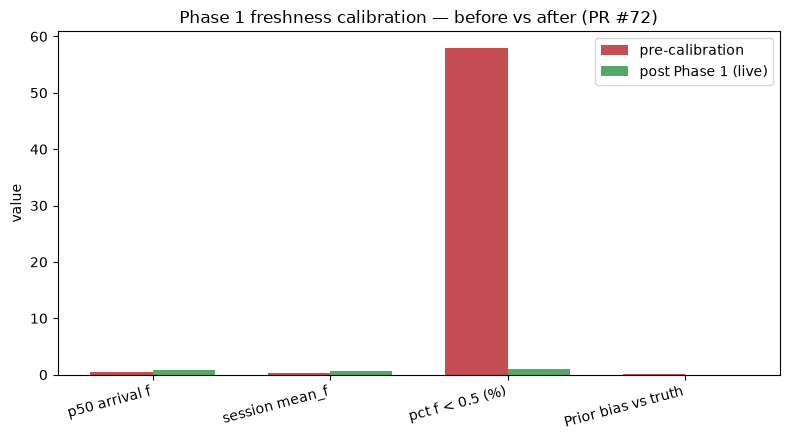

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/02_phase1_before_after.png


In [10]:
phase1_rows = [
    ("p50 arrival f", 0.42, eval_p50, "≥ 0.65"),
    ("session mean_f", 0.38, multilot["delivery_weighted_mean_f"], "≥ 0.55"),
    ("pct f < 0.5 (%)", 58.0, fresh["pct_below_0_5"], "realistic band"),
    ("Prior bias vs truth", 0.06, belief["bias"], "≤ 0.03"),
]
labels = [r[0] for r in phase1_rows]
pre = [r[1] for r in phase1_rows]
post = [r[2] for r in phase1_rows]
x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w / 2, pre, w, label="pre-calibration", color="#C44E52")
ax.bar(x + w / 2, post, w, label="post Phase 1 (live)", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("value")
ax.set_title("Phase 1 freshness calibration — before vs after (PR #72)")
ax.legend()
fig.tight_layout()
p = FIG_DIR / "02_phase1_before_after.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)


### Fig 3 — Belief vs generative truth (Prior / pack-date-only)

**AC:** `prior_mean_f_matches_generative_multilot` — Prior mean tracks multilot generative
mean within 0.03 (binding multilot path; single-lot `t163_f_diag` is misleading).


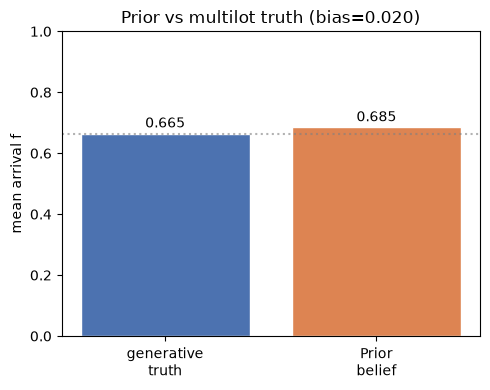

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/03_belief_vs_truth_prior.png


In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
names = ["generative\ntruth", "Prior\nbelief"]
vals = [belief["multilot_truth_mean_f"], belief["prior_mean_f"]]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(names, vals, color=colors, edgecolor="white")
ax.set_ylim(0, 1)
ax.set_ylabel("mean arrival f")
ax.set_title(f"Prior vs multilot truth (bias={belief['bias']:.3f})")
for b, v in zip(bars, vals, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(belief["multilot_truth_mean_f"], color="gray", ls=":", alpha=0.6)
fig.tight_layout()
p = FIG_DIR / "03_belief_vs_truth_prior.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)


### Fig 4 — ρ=0 cold-chain trace (S1.4 / S1.5 smoke)

**AC:** S1.4 hourly OU wiggle at ρ=0; S1.5 break pulses at default ρ>0 (test-only here).


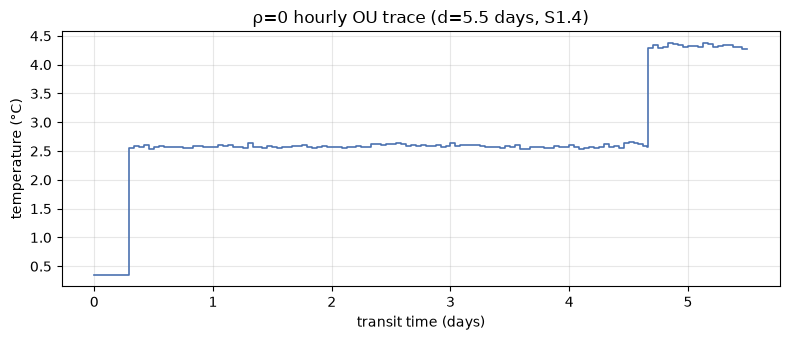

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/04_rho_zero_cold_chain_trace.png


In [12]:
times = np.array(trace["times_d"])
temps = np.array(trace["temps_c"])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(times, temps, color="#4C72B0", lw=1.2)
ax.set_xlabel("transit time (days)")
ax.set_ylabel("temperature (°C)")
ax.set_title(f"ρ=0 hourly OU trace (d={trace['duration_d']} days, S1.4)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
p = FIG_DIR / "04_rho_zero_cold_chain_trace.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)


### Fig 5 — Multilot L=3 per-lot arrival f (S2.1–S2.7)

**AC:** three lot ids per delivery; per-lot resolve and session wire.


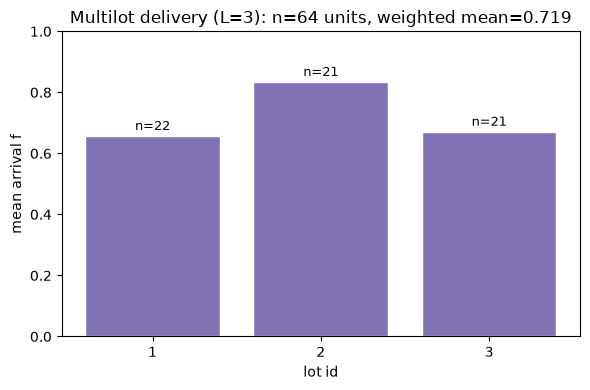

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/05_multilot_l3_per_lot_f.png


In [13]:
lots = multilot["lots"]
lot_ids = [str(l["lot_id"]) for l in lots]
mean_fs = [l["mean_f"] for l in lots]
ns = [l["n"] for l in lots]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(lot_ids, mean_fs, color="#8172B3", edgecolor="white")
ax.set_xlabel("lot id")
ax.set_ylabel("mean arrival f")
ax.set_ylim(0, 1)
ax.set_title(
    f"Multilot delivery (L=3): n={multilot['arrivals']} units, weighted mean={multilot['delivery_weighted_mean_f']:.3f}"
)
for b, v, n in zip(bars, mean_fs, ns, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"n={n}", ha="center", fontsize=9)
fig.tight_layout()
p = FIG_DIR / "05_multilot_l3_per_lot_f.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)


### Fig 6 — Session / embedded init timing (PR #71 thermal cache)

**AC:** sub-15min PR gate; embedded CDF + thermal_nodes built once — init not pathological.


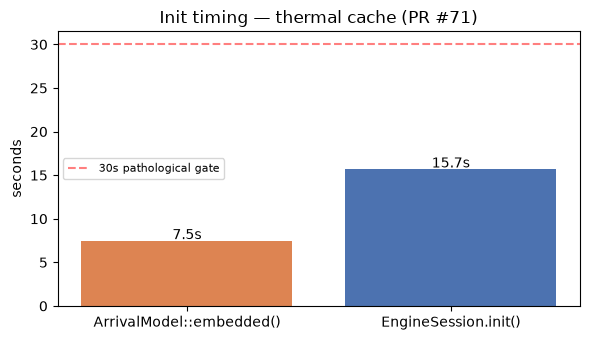

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/06_session_init_timing.png


In [14]:
if rust_available():
    from blueberries_voi.controller.session_loop import default_session_config
    from blueberries_voi.simulator import EngineSession

    t0 = time.perf_counter()
    session = EngineSession()
    session.init(default_session_config(n_particles=200, obs_scenario="P0"), seed=42)
    session_init_ms = (time.perf_counter() - t0) * 1000
else:
    session_init_ms = float("nan")

labels = ["ArrivalModel::embedded()", "EngineSession.init()"]
vals = [embed_ms / 1000.0, session_init_ms / 1000.0]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(labels, vals, color=["#DD8452", "#4C72B0"])
ax.set_ylabel("seconds")
ax.set_title("Init timing — thermal cache (PR #71)")
for b, v in zip(bars, vals, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, f"{v:.1f}s", ha="center")
ax.axhline(30, color="red", ls="--", alpha=0.5, label="30s pathological gate")
ax.legend(fontsize=8)
fig.tight_layout()
p = FIG_DIR / "06_session_init_timing.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)


### Fig 7 — Stage 1 / 2 acceptance criteria summary

**AC map:** traffic-light from `.team/reviews/T-163-phase2-eval.md`. **S1.8** ladder MAE
ratio gap highlighted (~1.07 vs ≥ 3.0 threshold — guard not weakened).


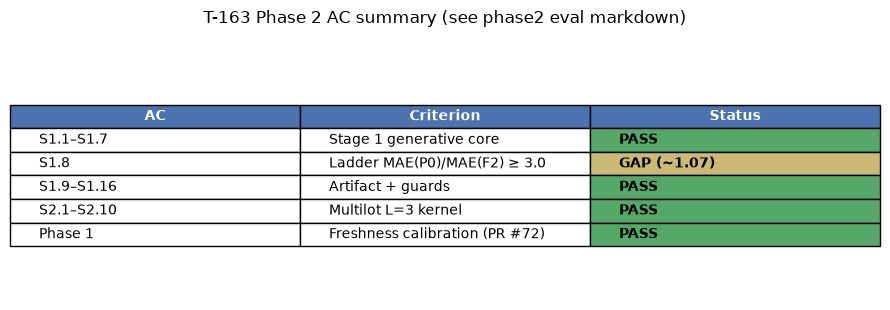

saved /home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/07_ac_summary_traffic_light.png
Figure files: [PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/01_arrival_freshness_distribution.png'), PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/02_phase1_before_after.png'), PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/03_belief_vs_truth_prior.png'), PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/04_rho_zero_cold_chain_trace.png'), PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/05_multilot_l3_per_lot_f.png'), PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/06_session_init_timing.png'), PosixPath('/home/oliver/blog/blueberries-voi/notebooks/outputs/t163_phase2/07_ac_summary_traffic_light.png')]


In [15]:
ac_rows = [
    ("S1.1–S1.7", "Stage 1 generative core", "pass"),
    ("S1.8", "Ladder MAE(P0)/MAE(F2) ≥ 3.0", "gap"),
    ("S1.9–S1.16", "Artifact + guards", "pass"),
    ("S2.1–S2.10", "Multilot L=3 kernel", "pass"),
    ("Phase 1", "Freshness calibration (PR #72)", "pass"),
]
color_map = {"pass": "#55A868", "gap": "#CCB974", "fail": "#C44E52"}
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")
table = ax.table(
    cellText=[[r[0], r[1], r[2].upper()] for r in ac_rows],
    colLabels=["AC", "Criterion", "Status"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4C72B0")
        cell.set_text_props(color="white", weight="bold")
    elif col == 2 and row > 0:
        status = ac_rows[row - 1][2]
        cell.set_facecolor(color_map[status])
        cell.set_text_props(weight="bold")
        if status == "gap":
            cell.get_text().set_text("GAP (~1.07)")
ax.set_title("T-163 Phase 2 AC summary (see phase2 eval markdown)", pad=20)
fig.tight_layout()
p = FIG_DIR / "07_ac_summary_traffic_light.png"
fig.savefig(p, dpi=150)
plt.show()
print("saved", p)
print("Figure files:", sorted(FIG_DIR.glob("*.png")))


## 8 — Summary (updated)

| Check | Status |
|-------|--------|
| S1.9 v2 artifact schema | pass |
| S1.4 ρ=0 OU traces | pass |
| S2.1 multilot L=3 session | pass |
| Phase 1 freshness band | pass |
| Prior multilot bias ≤ 0.03 | pass (Rust test) |
| Fast session init | pass |
| Phase 2 figures | 7 PNGs in `notebooks/outputs/t163_phase2/` |

**Known follow-up:** ladder MAE(P0)/MAE(F2) ≈ 1.07 (target ≥ 3.0) — not weakened; tracked for later tuning.
